In [66]:
import sys
from pathlib import Path
sys.path.append('../')
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import requests
import ot
import seaborn as sns
from sklearn.cluster import SpectralClustering
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import rbf_kernel
from scipy.sparse import csgraph
from matching_clustering.utils import LapOT
from matching_clustering.precompute_helpers import graph_laplacians, cost_matrix_c, build_cluster_matrix

## Begin by collecting the initial sets $A$ and $B$
We define
$A$ as the daily end-of-day price history over the past 1,256 trading days for the 50 largest companies by market capitalization in the U.S. equity market (S&P 500 constituents).


Similarly, we define
$B$ as the corresponding end-of-day price history over the same period for the 50 largest companies by market capitalization in the Japanese equity market, drawn primarily from the Nikkei 225 index (though not limited exclusively to its constituents).


Namely, we have
$$
A = (x_1, \dots, x_{50}), ~~~B = (y_1, \dots, y_{50})
$$
Where
$$
x_i = (P_i(1), \dots, P_i(1256)) \in \mathbb{R}^{1256}
$$
$$
y_j = (\tilde{P}_j(1), \dots, \tilde{P}_j(1256)) \in \mathbb{R}^{1256}
$$
And $P_i(t), \tilde{P}_j(t)$ are the values at the end of the trade day $t$ of the i'th and j'th companies of the American and Japanese markets respectively.
##Normalize X and Y
We normalize the trade history of each company by the value of it's stock at the end of the first trade day, so all the companies start value 1.


We do that in order to neutralize scaling problems that can occur from differences in the currencies (\$ to &yen;) and different starting points.

### Load and visualize the financial data 
#### The data is taken for 1256 trading days starting from January first 2020


S&P 500 index-to-name mapping (first 10):
0 -> Nvidia
1 -> Apple Inc.
2 -> Microsoft
3 -> Amazon
4 -> Alphabet Inc. (Class A)
5 -> Alphabet Inc. (Class C)
6 -> Broadcom
7 -> Meta Platforms
8 -> Tesla, Inc.
9 -> Berkshire Hathaway

Japan index-to-name mapping (first 10):
0 -> TOYOTA MOTOR CORP
1 -> MITSUBISHI UFJ FINANCIAL GROUP 
2 -> HITACHI
3 -> SOFTBANK GROUP CORP
4 -> SUMITOMO MITSUI FINANCIAL GROUP
5 -> SONY GROUP CORPORATION
6 -> FAST RETAILING CO LTD
7 -> TOKYO ELECTRON
8 -> ADVANTEST CORP
9 -> MIZUHO FINANCIAL GROUP


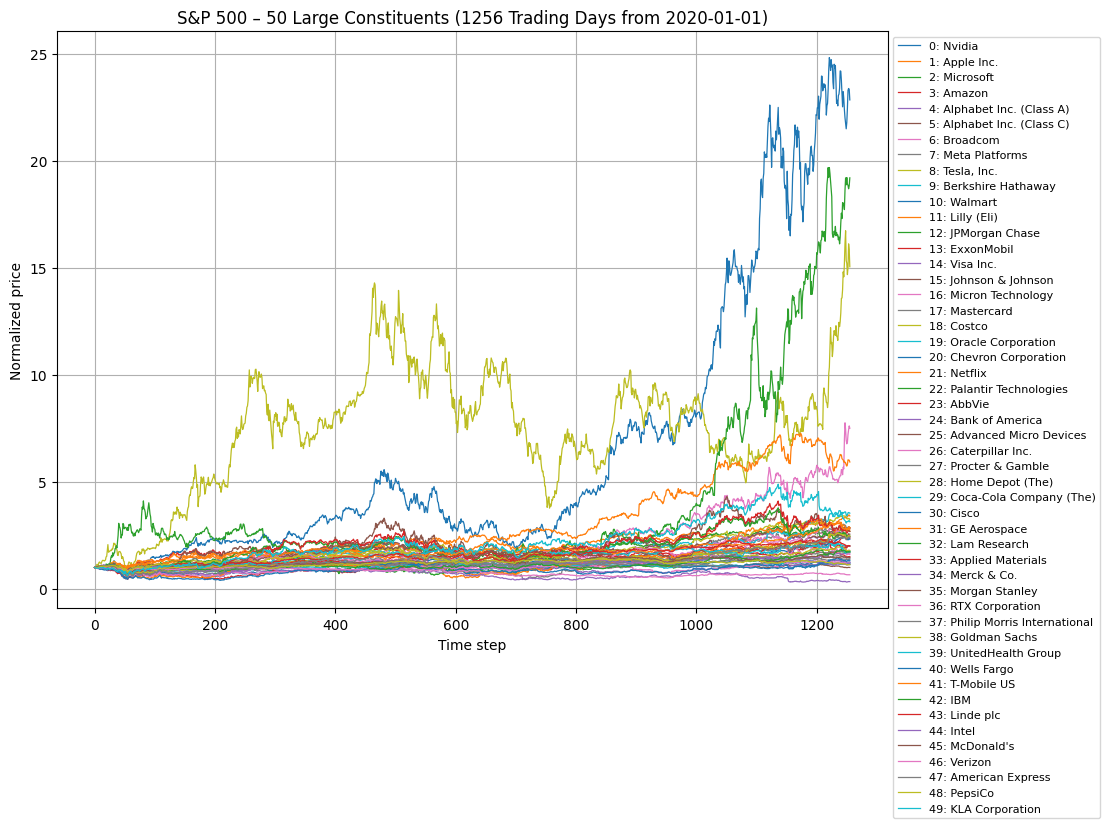

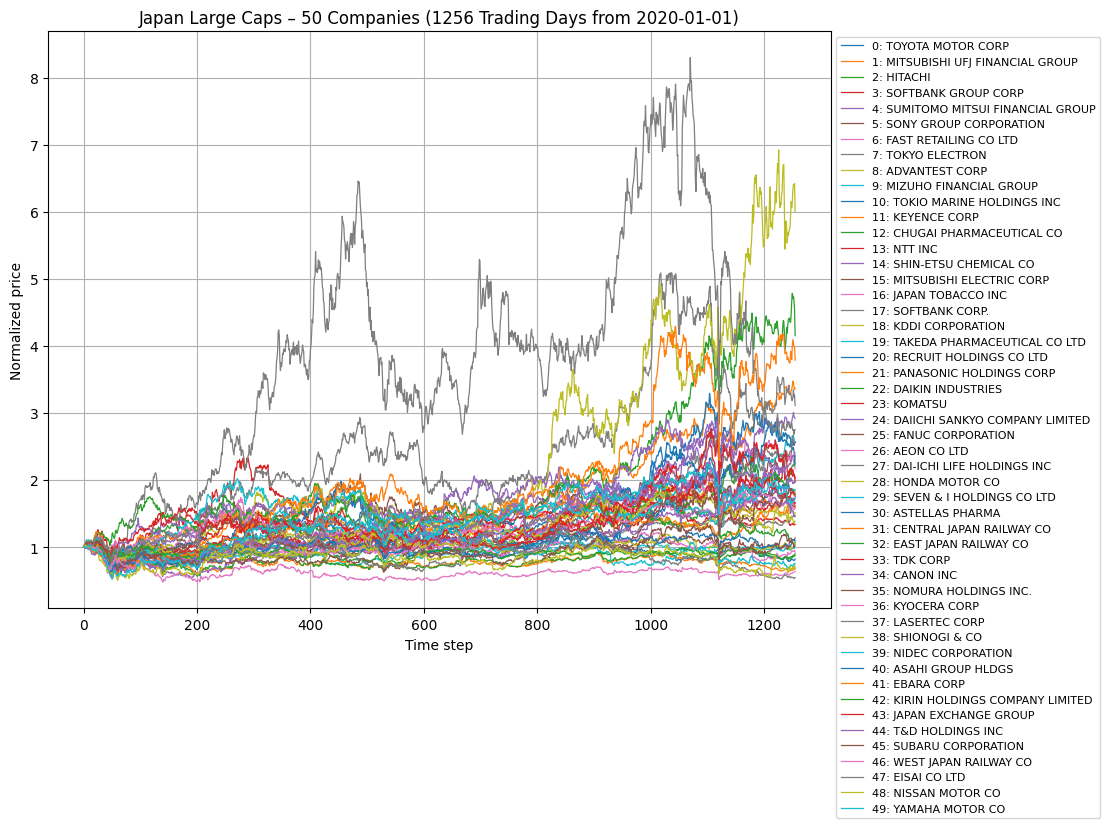

In [67]:
# Load the precomputed normalized price data and company names for both the S&P 500 and Japan datasets
X_norm = np.load("../matching_clustering/Precomputed_finance_data/X_norm.npy")
Y_norm = np.load("../matching_clustering/Precomputed_finance_data/Y_norm.npy")
sp500_names = np.load("../matching_clustering/Precomputed_finance_data/sp500_names.npy", allow_pickle=True)
japan_names = np.load("../matching_clustering/Precomputed_finance_data/japan_names.npy", allow_pickle=True)
japan_tickers = np.load("../matching_clustering/Precomputed_finance_data/japan_tickers.npy", allow_pickle=True)
sp500_tickers = np.load("../matching_clustering/Precomputed_finance_data/sp500_tickers.npy", allow_pickle=True)

N_COMPANIES = X_norm.shape[0]
T = X_norm.shape[1]
START_DATE = "2020-01-01"


sp500_index_to_name = {i: name for i, name in enumerate(sp500_names)}
print("\nS&P 500 index-to-name mapping (first 10):")
for i in range(min(10, N_COMPANIES)):
    print(i, "->", sp500_index_to_name[i])


japan_index_to_name = {i: name for i, name in enumerate(japan_names)}
print("\nJapan index-to-name mapping (first 10):")
for i in range(min(10, N_COMPANIES)):
    print(i, "->", japan_index_to_name[i])    
# ============================================================
# 4) Plotting X and Y (with legends)
# ============================================================

time_axis = np.arange(T)

# -----------------------
# Plot X (S&P 500)
# -----------------------
plt.figure(figsize=(14, 8))
for i in range(N_COMPANIES):
    plt.plot(
        time_axis,
        X_norm[i, :],
        linewidth=0.9,
        label=f"{i}: {sp500_index_to_name[i]}"
    )
plt.title(f"S&P 500 – 50 Large Constituents ({T} Trading Days from {START_DATE})")
plt.xlabel("Time step")
plt.ylabel("Normalized price")
plt.grid(True)
plt.legend(loc="upper left", bbox_to_anchor=(1, 1), fontsize=8)
plt.tight_layout(rect=[0, 0, 0.8, 1])

# Save the figure to a PDF file in the "Figures" directory
base_dir = Path.cwd()  # instead of __file__
output_path = base_dir / "Figures" / "stockmarket_figures" / "S&P_500_data.pdf"
output_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(output_path, bbox_inches="tight")

plt.show()



# -----------------------
# Plot Y (Japan)
# -----------------------
plt.figure(figsize=(14, 8))
for i in range(N_COMPANIES):
    plt.plot(
        time_axis,
        Y_norm[i, :],
        linewidth=0.9,
        label=f"{i}: {japan_index_to_name[i]}"
    )
plt.title(f"Japan Large Caps – 50 Companies ({T} Trading Days from {START_DATE})")
plt.xlabel("Time step")
plt.ylabel("Normalized price")
plt.grid(True)
plt.legend(loc="upper left", bbox_to_anchor=(1, 1), fontsize=8)
plt.tight_layout(rect=[0, 0, 0.8, 1])

# Save the figure to a PDF file in the "Figures" directory
base_dir = Path.cwd()  # instead of __file__
output_path = base_dir / "Figures" / "stockmarket_figures" / "Japan_financial_data.pdf"
output_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(output_path, bbox_inches="tight")

plt.show()

### Next, we decide on a measure that will indicate the behaviour of each stock.
#### We can either use
$$
R^{X}_i(t+1) =log(x_i(t+1)) - log(x_i(t)),
$$

$$
R^{Y}_j(t+1) =log(y_j(t+1)) - log(y_j(t)).
$$

#### Or,  calculate instead
$$
R_i^{X}(t+1) = \frac{x_i(t+1) - x_i(t)}{x_i(t)},
$$

$$
R_j^{Y}(t+1) = \frac{y_j(t+1) - y_j(t)}{y_j(t)}.
$$

#### For the second option we calculate 
$$
P_{market} = \frac{1}{n}\sum_{k=1}^nP_k, ~~~~R_{market}(t) =\frac{P_{market}(t) - P_{market}(t-1)}{P_{market}(t-1)}
$$
#### As well

In [68]:
def compute_R(x, y, log=False):

  if log:
      # X and Y must be of shape (50, 1256)

      # Compute log-returns along the time axis
      log_R_X = np.log(x[:, 1:]) - np.log(x[:, :-1])   # shape (50, 1255)
      log_R_Y = np.log(y[:, 1:]) - np.log(y[:, :-1])   # shape (50, 1255)

      return log_R_X, log_R_Y, None, None, None, None
  else:
      # Compute log-returns along the time axis
      R_X = (x[:, 1:] - x[:, :-1])/x[:, :-1]   # shape (50, 1255)
      R_Y = (y[:, 1:] - y[:, :-1])/ y[:, :-1]   # shape (50, 1255)

      P_X_market = np.mean(X_norm, axis=0)
      P_Y_market = np.mean(Y_norm, axis=0)
      R_X_market = P_X_market[1:]/ P_X_market[:-1] - 1.0
      R_Y_market = P_Y_market[1:]/ P_Y_market[:-1] - 1.0
      return R_X, R_Y, R_X_market, R_Y_market, P_X_market, P_Y_market

# Compute R_X, R_Y, R_X_market, R_Y_market, P_X_market, P_Y_market:
R_X, R_Y, R_X_market, R_Y_market, P_X_market, P_Y_market = compute_R(X_norm, Y_norm)

### The point clouds $X$ and $Y$ for the experiment
#### We take our point clouds $X$ and $Y$ to be
$$
X = \{R_1^X,\dots,R^X_{50}\} \subset \mathbb{R}^{1255}, ~~~ Y = \{R^Y_1, \dots, R^Y_{50} \} \subset \mathbb{R}^{1255}
$$

### Next, introduce a notion of similarity between two stocks in a cloud
$$
W\_X_{ij} = \frac{Cov(R^X_i, R^X_j)}{\sigma_i^X \sigma_j^X},
$$


$$
W\_Y_{ij} = \frac{Cov(R^Y_i, R^Y_j)}{\sigma_i^Y \sigma_j^Y}.
$$
### On top of these we furher calculate the graph Laplacians $L_X$ and $L_Y$.

In [69]:
def compute_W(r_x, r_y):
    # R_X, R_Y are assumed to have shape (50, 1255)
    N = r_x.shape[1]           # 1255
    denom = N - 1              # 1254

    # ----- For X -----
    # Mean per asset (over time)
    mean_RX = r_x.mean(axis=1, keepdims=True)          # (50, 1)

    # Centered returns
    RX_centered = r_x - mean_RX                        # (50, 1255)

    # Covariance matrix (50 x 50)
    Cov_X = (RX_centered @ RX_centered.T) / denom      # (50, 50)

    # Variances per asset (diagonal)
    var_X = np.diag(Cov_X)                             # (50,)
    sigma_X = np.sqrt(var_X)                           # (50,)



    # Correlation / normalized covariance matrix W_X
    W_X = Cov_X / (sigma_X[:, None] * sigma_X[None, :])


    # ----- For Y -----
    mean_RY = r_y.mean(axis=1, keepdims=True)          # (50, 1)
    RY_centered = r_y - mean_RY                        # (50, 1255)

    Cov_Y = (RY_centered @ RY_centered.T) / denom      # (50, 50)
    var_Y = np.diag(Cov_Y)                             # (50,)
    sigma_Y = np.sqrt(var_Y)                           # (50,)



    W_Y = Cov_Y / (sigma_Y[:, None] * sigma_Y[None, :])

    return W_X, W_Y

# Compute similarity matrices W_X and W_Y from R_X and R_Y:
W_X, W_Y = compute_W(R_X, R_Y)

# Make sure all entries of W_X and W_Y are at most 1 (due to numerical issues, some entries might be slightly above 1)
W_X = np.minimum(W_X, 1)
W_Y = np.minimum(W_Y, 1)



### Next, we calculate a different similarity measure on the basis of which we calculate the distance profiles of each cloud
$$
W\_X_{ij} = \frac{ Cov(R_i^X, \frac{P_j}{P_m} \cdot R^X_j)} {Var(R_{market}^X)},
$$
$$
W\_Y_{ij} = \frac{ Cov(R^Y_i, \frac{\tilde{P}_j}{P^X_{market}} \cdot R^Y_j)} {Var(R_{market}^Y)}.
$$

In [70]:
# R_X, R_Y are assumed to have shape (50, 1255)
def compute_W_for_C(r_x, r_y, x, y, p_x_market, p_y_market, r_x_market, r_y_market):

    N = r_x.shape[1]           # 1255
    denom = N - 1              # 1254

    # ----- For X -----
    # Mean per asset (over time)

    RX_PX_market = (r_x * x[:, :-1])/(p_x_market[:-1])
    mean_RX_PX_market = RX_PX_market.mean(axis=1, keepdims=True)
    RX_PX_market_centered = RX_PX_market - mean_RX_PX_market


    mean_RX = r_x.mean(axis=1, keepdims=True)          # (50, 1)

    # Centered returns
    RX_centered = r_x - mean_RX                        # (50, 1255)

    mean_RX_market = r_x_market.mean()
    RX_market_centered = R_X_market - mean_RX_market

    var_RX_market = RX_market_centered @ RX_market_centered.T / denom


    # Covariance matrix (50 x 50)
    Cov_X = (RX_centered @ RX_PX_market_centered.T) / denom      # (50, 50)



    # Correlation / normalized covariance matrix W_X
    W_X_matching = Cov_X / var_RX_market

    # ----- For Y -----
    RY_PY_market = (r_y * y[:, :-1])/(p_y_market[:-1])
    mean_RY_PY_market = RY_PY_market.mean(axis=1, keepdims=True)
    RY_PY_market_centered = RY_PY_market - mean_RY_PY_market


    mean_RY = r_y.mean(axis=1, keepdims=True)          # (50, 1)
    RY_centered = r_y - mean_RY                        # (50, 1255)

    mean_RY_market = r_y_market.mean()
    RY_market_centered = R_Y_market - mean_RY_market

    var_RY_market = RY_market_centered @ RY_market_centered.T / denom



    # Covariance matrix (50 x 50)
    Cov_Y = (RY_centered @ (RY_PY_market_centered).T) / denom      # (50, 50)


    W_Y_matching = Cov_Y / var_RY_market
    return W_X_matching, W_Y_matching

# Compute similarity matrices on the basis of which we will calculate the distance profile C:
W_X_matching, W_Y_matching = compute_W_for_C(R_X, R_Y, X_norm, Y_norm, P_X_market, P_Y_market, R_X_market, R_Y_market)

### Next, we transform the similarity matrices used as basis for the computation of $L_X, L_Y$ as follows
$$
W_{ij} ⟶ \sqrt{2(1 - W_{ij})},
$$
### So, the values of the potential similarity between points in a cloud move from $[-1, 1]$ to $[0, 2]$.
##### Also notice that $W_{ij} \leq W_{ik} + W_{kj}$.

In [71]:
# Assume W_X and W_Y are (50, 50) correlation-like matrices with values in [-1, 1]

# Elementwise transformation
DX = np.sqrt(2 * (1 - W_X))
DY = np.sqrt(2 * (1 - W_Y))



## Applying $\text{Refined Simultaneous Clustering}$ ($\text{RSC}$) on clouds $X$ and $Y$

## Calculate $L_X$ and $L_Y$
Notice- we want to have more control on the radius of similarity and have gaussian decay and hence we first transform
$$
W_{ij} ⟶ \exp (-(\frac{W_{ij}}{2\sigma})^2),
$$

On top of which we calculate the graph Laplacian according to
$$
L = \text{diag}(W\mathbf{1}_n) - W.
$$

In [72]:
# Asign the value of sigma
sigma = 0.5

# Same number of points in both clouds --> number of companies in both datasets is the same
n = X_norm.shape[0]



# Step 2: Compute the similarity matrices W_X, W_Y based on the gaussian similarity function.
W_X_adjace = np.exp(-DX**2/(2*sigma**2))
W_Y_adjace = np.exp(-DY**2/(2*sigma**2))

## Step 3: Compute the unnormalized graph Laplacians L_X and L_Y from W_X and W_Y.
L_X = csgraph.laplacian(W_X_adjace, normed=False)
L_Y = csgraph.laplacian(W_Y_adjace, normed=False)


### Calculate the $\beta$ parameter for each company in each cloud for later comparison

$$
\beta_i = \frac{Cov(R^X_i, R^X_{market})}{Var(R^X_{market})}, ~~~~ \tilde{\beta}_j = \frac{Cov(R^Y_i, R^Y_{market})}{Var(R^Y_{market})}.
$$

In [73]:
def compute_beta(r_x, r_y, r_x_market, r_y_market):

    N = r_x.shape[1]           # 1255
    denom = N - 1              # 1254

    # ----- For X -----
    # Mean per asset (over time)

    mean_RX_market = r_x_market.mean()
    RX_market_centered = r_x_market - mean_RX_market


    mean_RX = r_x.mean(axis=1, keepdims=True)          # (50, 1)

    # Centered returns
    RX_centered = r_x - mean_RX                        # (50, 1255)

    var_RX_market = RX_market_centered @ RX_market_centered.T / denom


    # Covariance matrix (50 x 50)
    Cov_X = (RX_centered @ RX_market_centered.T) / denom      # (50, 50)

    # # Variances per asset (diagonal)
    # var_X = np.diag(Cov_X)                             # (50,)
    # sigma_X = np.sqrt(var_X)                           # (50,)
    # print(f'This is sigma_X:{sigma_X}')


    # Correlation / normalized covariance matrix W_X
    Beta_X = Cov_X / var_RX_market

    # ----- For Y -----


    mean_RY = r_y.mean(axis=1, keepdims=True)          # (50, 1)
    RY_centered = r_y - mean_RY                        # (50, 1255)

    mean_RY_market = R_Y_market.mean()
    RY_market_centered = R_Y_market - mean_RY_market

    var_RY_market = RY_market_centered @ RY_market_centered.T / denom


    #


    Cov_Y = (RY_centered @ (RY_market_centered).T) / denom      # (50, 50)
    # var_Y = np.diag(Cov_Y)                             # (50,)
    # sigma_Y = np.sqrt(var_Y)                           # (50,)
    # print(f'This is sigma_X:{sigma_Y}')


    Beta_Y = Cov_Y / var_RY_market
    return Beta_X, Beta_Y
Beta_X, Beta_Y = compute_beta(R_X, R_Y, R_X_market, R_Y_market)

### Now calculate the matrix
$$
(\text{beta\_diff})_{ij} = |\beta_i - \tilde{\beta}_j|
$$

In [74]:
Beta_X = Beta_X.reshape(-1, 1)
Beta_Y = Beta_Y.reshape(-1, 1)
diff_beta = np.abs(Beta_X - Beta_Y.T)


### Calculate the transportation cost matrix $C$ and plot the difference $C - \text{beta\_diff}$

Here we calculate $C$ for the uniform marginal distributions case.
In addition we plot $C - \text{beta}\_\text{dif}$.

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    2.7s
[Parallel(n_jobs=-1)]: Done 1420 tasks      | elapsed:    2.7s
[Parallel(n_jobs=-1)]: Done 2500 out of 2500 | elapsed:    2.8s finished


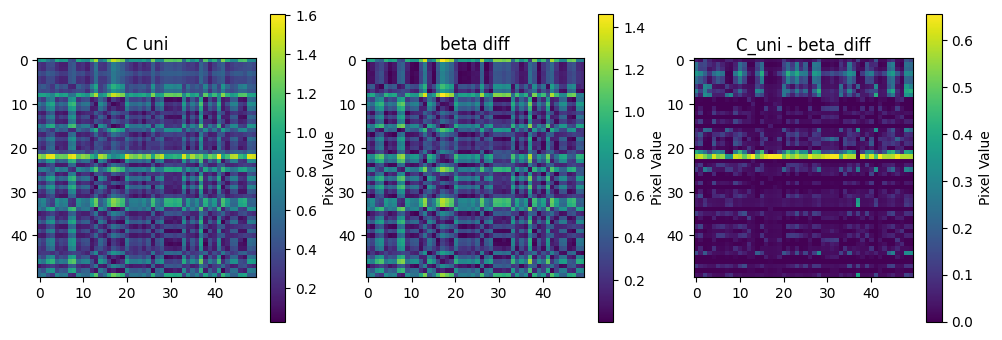

In [75]:
W1_matrix_uniform = cost_matrix_c(W_X_matching, W_Y_matching)

# Calculate the difference between the uniform cost matrix and the beta difference matrix
interesting = W1_matrix_uniform - diff_beta
matrices = [W1_matrix_uniform, diff_beta, interesting]
titles = ['C uni', 'beta diff', 'C_uni - beta_diff']
fig, axes = plt.subplots(1, 3, figsize=(12, 4))  # 1 row, 3 columns
for i, ax in enumerate(axes):
    im = ax.imshow(matrices[i], cmap='viridis', interpolation='nearest')
    ax.set_title(titles[i])
    # ax.axis('off')  # optional: hide axis ticks
    cbar = plt.colorbar(im)
    cbar.set_label('Pixel Value')  # optional: add label to the bar

### Solving $\text{LapOT}$, obtaining the optimal coupling $\pi^\star$ 

In [76]:
# Transportation cost matrix
C = W1_matrix_uniform


# # # Laplacian matrices
K = L_X
L = L_Y




# 1. Fixed-point (lambda should not be too small)
# Set lambda_x, lambda_y and lambda
l = 0.7 # entropic regularization parameter
l_x = 4 # Laplacian regularization parameter for X
l_y = 4 # Laplacian regularization parameter for Y


prob = LapOT(K, L, C, l, l_x, l_y)
pi_fp_uni = prob.solve(method='fp', verbose=True)



### Uncomment the following for visualization of the cost matrix and the optimal transport plan


# matrices = [pi_fp_uni, C]
# titles = ['pi unifrom', 'C']
# fig, axes = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 3 columns
# for i, ax in enumerate(axes):
#     im = ax.imshow(matrices[i], cmap='viridis', interpolation='nearest')
#     ax.set_title(titles[i])
#     ax.axis('off')  # optional: hide axis ticks

Initialization: objective = -5.71852627558474
Implement fixed point algorithm
max of entropy term :-6.151634817409381 
 max of main term: 0.4089647530084334
Iteration 1: objective = -5.742670064400947, objective relative change = -0.004222029881945187, pi change (L1) = 0.2036452515218016
max of entropy term :-6.1534004450903295 
 max of main term: 0.4106963941699711
Iteration 2: objective = -5.742704050920358, objective relative change = -5.918243435559003e-06, pi change (L1) = 0.007670450453850419
max of entropy term :-6.153327873279355 
 max of main term: 0.4106237360158478
Iteration 3: objective = -5.742704137263507, objective relative change = -1.5035277434684495e-08, pi change (L1) = 0.00035200363372876254
max of entropy term :-6.153331445232718 
 max of main term: 0.4106273076086209
Iteration 4: objective = -5.742704137624097, objective relative change = -6.279093814313084e-11, pi change (L1) = 1.930494168455568e-05
max of entropy term :-6.153331242857794 
 max of main term: 0.41

### Calculate $\pi^X_{switch}$, $\pi^Y_{switch}$ for RSC (Refined Simultaneous Clustering).
#### Update the similarity matrices
$$
W^X ⟶ W^X \bullet \pi^X_{switch},
$$

$$
W^Y ⟶ W^Y \bullet \pi^Y_{switch}.
$$

#### Add $\epsilon$ to $W$ to make it a similarity matrix of a fully connected graph.

In [77]:
PI_for_X = build_cluster_matrix(pi_fp_uni, 2)
PI_for_Y = build_cluster_matrix(pi_fp_uni.T, 2)
epsilon = 1e-15
new_W_X = PI_for_X*W_X_adjace + epsilon
new_W_Y = PI_for_Y*W_Y_adjace + epsilon

### Next, run the two following cells to see the low rank structure of $\pi^\star$


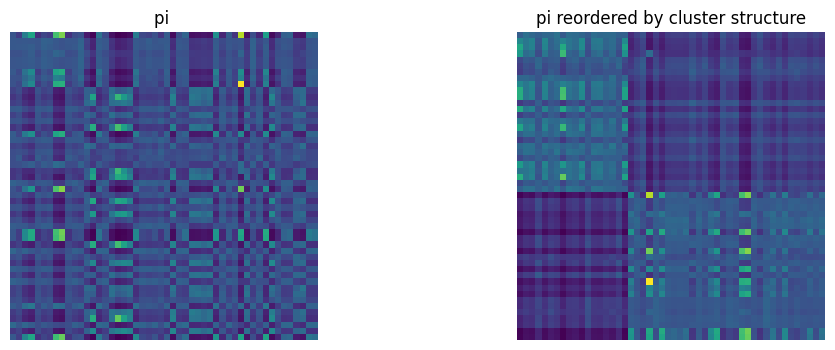

In [78]:
def matrix_to_labels(M):
    """
    Convert an NxN cluster-indicator matrix M (M[i,j] = 1 iff i,j in same cluster)
    into a label vector of length N.
    """
    # Sort unique rows and get inverse index mapping
    # Rows belonging to the same cluster are identical
    _, labels = np.unique(M, axis=0, return_inverse=True)
    return labels


def group_by_labels(A, x, y):
    """
    Reorder rows and columns of A so that rows with the same label in x
    are contiguous, and columns with the same label in y are contiguous.

    Parameters
    ----------
    A : (n, n) ndarray
        Square matrix.
    x : (n,) array_like
        Row labels.
    y : (n,) array_like
        Column labels.

    Returns
    -------
    A_reordered : (n, n) ndarray
        Matrix with rows and columns reordered.
    row_order : (n,) ndarray
        Indices of original rows in the new order.
    col_order : (n,) ndarray
        Indices of original columns in the new order.
    """
    x = np.asarray(x)
    y = np.asarray(y)

    # Get permutation that groups equal labels together.
    # np.argsort will place identical labels next to each other.
    row_order = np.argsort(x)
    col_order = np.argsort(y)

    A_reordered = A[row_order][:, col_order]
    return A_reordered, row_order, col_order



labels_x = matrix_to_labels(PI_for_X)
labels_y = matrix_to_labels(PI_for_Y)

A_reordered, row_order, col_order = group_by_labels(pi_fp_uni, labels_x, labels_y)


matrices = [pi_fp_uni, A_reordered]
titles = ['pi ', 'pi reordered by cluster structure']
fig, axes = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 3 columns
for i, ax in enumerate(axes):
    im = ax.imshow(matrices[i], cmap='viridis', interpolation='nearest')
    ax.set_title(titles[i])
    ax.axis('off')  # optional: hide axis ticks

## Refined Spectral Clustering
### Step 1:
Run Spectral Clustering on the basis of the refined similarity matrices and calculate the label matrices for the clustering of both clouds.

In [79]:


def spectral_same_cluster_matrix(W, n_clusters=5, random_state=0):
    """
    W : (n, n) adjacency / similarity matrix
    n_clusters : number of clusters for spectral clustering

    Returns:
        labels : shape (n,) integer cluster labels
        A      : (n, n) binary same-cluster matrix
                 A[i,j] = 1 iff labels[i] == labels[j]
    """
    n = W.shape[0]

    # Spectral clustering with precomputed affinity
    sc = SpectralClustering(
        n_clusters=n_clusters,
        affinity='precomputed',
        assign_labels='kmeans',
        random_state=random_state,
    )
    labels = sc.fit_predict(W)  # shape (n,)

    # Build same-cluster matrix
    A = (labels[:, None] == labels[None, :]).astype(int)  # (n, n)

    return labels, A




# choose number of clusters 
k_X = 5
k_Y = 5

# Apply spectral clustering to the refined similarity matrices
labels_X, A = spectral_same_cluster_matrix(new_W_X, n_clusters=k_X)
labels_Y, B = spectral_same_cluster_matrix(new_W_Y, n_clusters=k_Y)

## Step 2:
### Plot results based on the clustering label matrices, we permute the rows and columns of the optimal coupling $\pi^\star$ according to $\pi^X_{switch}$ and $\pi^Y_{switch}$ to see the broad structure of the clusters.

(50, 50)


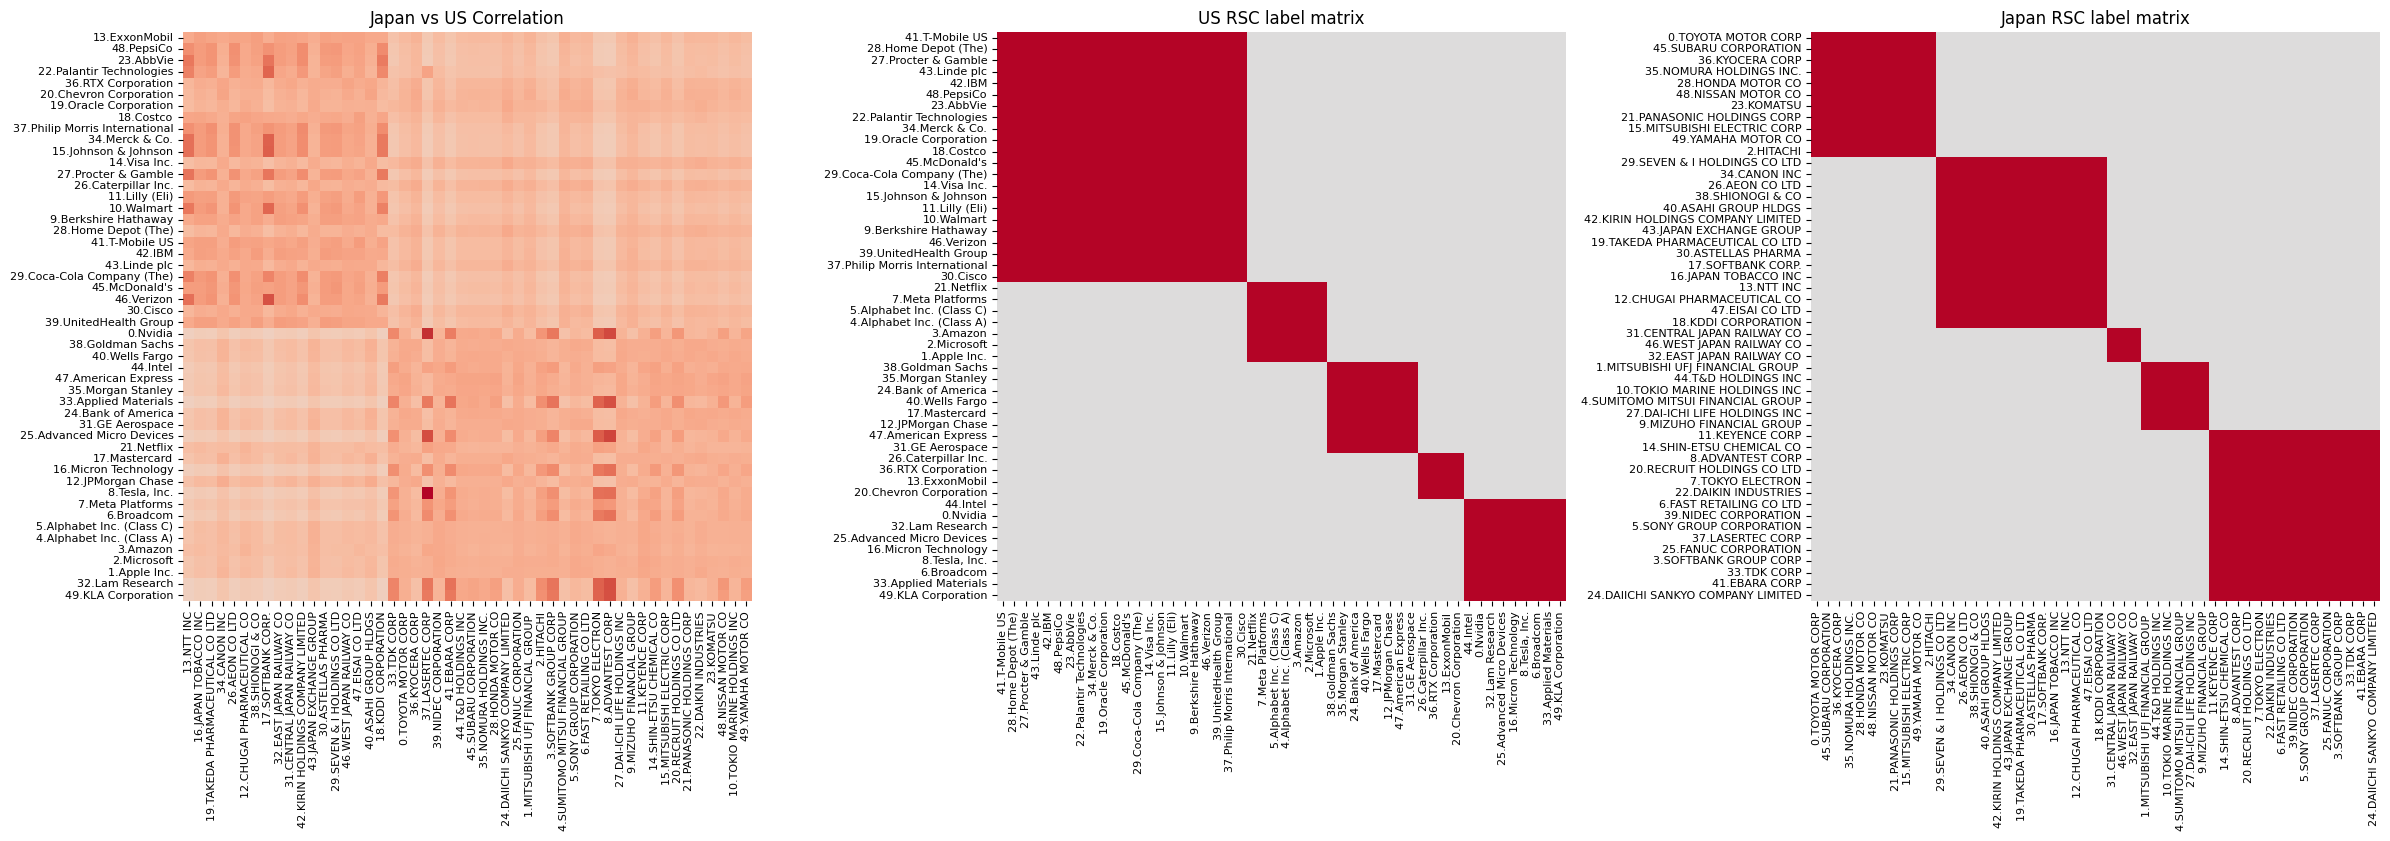

In [80]:
A_plot = group_by_labels(A, labels_X, labels_X)[0]
B_plot = group_by_labels(B, labels_Y, labels_Y)[0]


names_US = []
for i in range(50):
  names_US.append(str(i) + '.'+sp500_index_to_name[i])

names_Japan = []
for i in range(50):
  names_Japan.append(str(i) + '.'+japan_index_to_name[i])

M = group_by_labels(pi_fp_uni, labels_X, labels_Y)
print(M[0].shape)
x = np.asarray(labels_x)
y = np.asarray(labels_y)

x_cluster = np.asarray(labels_X)
y_cluster = np.asarray(labels_Y)

# Get permutation that groups equal labels together.
# np.argsort will place identical labels next to each other.
row_order = np.argsort(x)
col_order = np.argsort(y)

order_cluster_US = np.argsort(x_cluster)
order_cluster_Japan = np.argsort(y_cluster)

names_US = np.array(names_US, dtype=object)
names_Japan = np.array(names_Japan, dtype=object)

names_US_reordered = names_US[row_order]
names_Japan_reordered = names_Japan[col_order]

names_US_cluster = names_US[order_cluster_US]
names_Japan_cluster = names_Japan[order_cluster_Japan]




# Create 1 row with 3 columns for the 3 heatmaps
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

# --- Heatmap 1 ---
sns.heatmap(
    A_reordered,
    xticklabels=names_Japan_reordered,
    yticklabels=names_US_reordered,
    cmap="coolwarm",
    center=0,
    square=True,
    cbar=False,
    ax=axes[0]
)
axes[0].set_title("Japan vs US Correlation")
axes[0].tick_params(axis='x', rotation=90, labelsize=8)
axes[0].tick_params(axis='y', rotation=0, labelsize=8)

# --- Heatmap 2 ---
sns.heatmap(
    A_plot,                      # <- second matrix
    xticklabels=names_US_cluster,             # <- second x labels
    yticklabels=names_US_cluster,             # <- second y labels
    cmap="coolwarm",
    center=0,
    square=True,
    cbar=False,
    ax=axes[1]
)
axes[1].set_title("US RSC label matrix")
axes[1].tick_params(axis='x', rotation=90, labelsize=8)
axes[1].tick_params(axis='y', rotation=0, labelsize=8)

# --- Heatmap 3 ---
sns.heatmap(
    B_plot,                      # <- third matrix
    xticklabels=names_Japan_cluster,
    yticklabels=names_Japan_cluster,
    cmap="coolwarm",
    center=0,
    square=True,
    cbar=False,
    ax=axes[2]
)
axes[2].set_title("Japan RSC label matrix")
axes[2].tick_params(axis='x', rotation=90, labelsize=8)
axes[2].tick_params(axis='y', rotation=0, labelsize=8)

plt.tight_layout()

# Save the figure to a PDF file in the "Figures" directory
base_dir = Path.cwd()  # instead of __file__
output_path = base_dir / "Figures" / "stockmarket_figures" /  "Stock_Market_RSC_results.pdf"
output_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(output_path, bbox_inches="tight")
plt.show()